# ML Spotify Dataset exploration

## Import Libraries

In [54]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Exploring 'data.csv'

In [55]:
# all data files paths
DATA_PATH =             Path("data/data.csv")
DATA_BY_ARTIST_PATH =   Path("data/data_by_artist.csv")
DATA_BY_GENRES_PATH =   Path("data/data_by_genres.csv")
DATA_BY_YEAR_PATH =     Path("data/data_by_year.csv")
DATA_W_GENRES_PATH =    Path("data/data_w_genres.csv")

In [56]:
# load file to dataframe
df = pd.read_csv(DATA_PATH)
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [58]:
# dropping rows with missing values and dropping identifier columns
df = df.dropna()
cols_to_drop = ["id", "artists", "name"]
df = df.drop(columns=cols_to_drop, errors="ignore")
df.head()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,0.279,831667,0.211,0,0.878000,10,0.665,-20.096,1,4,1921,0.0366,80.954
1,0.9630,1921,0.732,0.819,180533,0.341,0,0.000000,7,0.160,-12.441,1,5,1921,0.4150,60.936
2,0.0394,1921,0.961,0.328,500062,0.166,0,0.913000,3,0.101,-14.850,1,5,1921,0.0339,110.339
3,0.1650,1921,0.967,0.275,210000,0.309,0,0.000028,5,0.381,-9.316,1,3,1921,0.0354,100.109
4,0.2530,1921,0.957,0.418,166693,0.193,0,0.000002,3,0.229,-10.096,1,2,1921,0.0380,101.665


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   danceability      170653 non-null  float64
 4   duration_ms       170653 non-null  int64  
 5   energy            170653 non-null  float64
 6   explicit          170653 non-null  int64  
 7   instrumentalness  170653 non-null  float64
 8   key               170653 non-null  int64  
 9   liveness          170653 non-null  float64
 10  loudness          170653 non-null  float64
 11  mode              170653 non-null  int64  
 12  popularity        170653 non-null  int64  
 13  release_date      170653 non-null  object 
 14  speechiness       170653 non-null  float64
 15  tempo             170653 non-null  float64
dtypes: float64(9), int64

no missing nas

In [60]:
popularity_threshold = 70
hit_song_count = (df["popularity"] > popularity_threshold).sum()
print(f"total number of songs: ", len(df))
print(f"number of songs with pop over {popularity_threshold}: ", hit_song_count)
print(f"percentage of songs with pop over {popularity_threshold}: ", hit_song_count / len(df) * 100)

total number of songs:  170653
number of songs with pop over 70:  4265
percentage of songs with pop over 70:  2.4992235706374926


<Axes: >

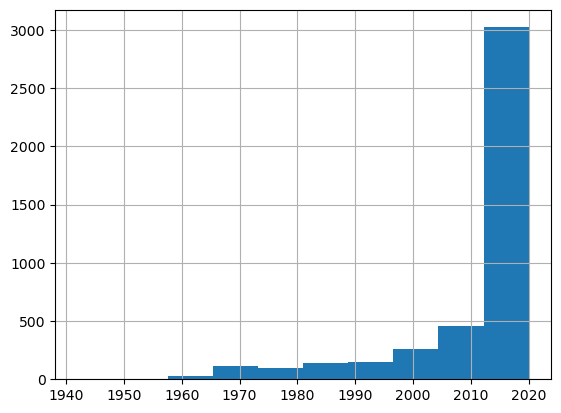

In [61]:
# checking year of hit songs
hit_songs = df[df["popularity"] > popularity_threshold]
hit_songs["year"].hist()

In [62]:
# creating binary target column 'hit'
df["hit"] = (df["popularity"] >= popularity_threshold).astype(int)
# getting hit value_counts
df["hit"].value_counts(normalize=True)

hit
0    0.970613
1    0.029387
Name: proportion, dtype: float64

In [63]:
df.isnull().sum().sort_values(ascending=False)

valence             0
liveness            0
tempo               0
speechiness         0
release_date        0
popularity          0
mode                0
loudness            0
key                 0
year                0
instrumentalness    0
explicit            0
energy              0
duration_ms         0
danceability        0
acousticness        0
hit                 0
dtype: int64

In [64]:
df["year"].describe()

count    170653.000000
mean       1976.787241
std          25.917853
min        1921.000000
25%        1956.000000
50%        1977.000000
75%        1999.000000
max        2020.000000
Name: year, dtype: float64

In [65]:
df["hit"].value_counts()
df["hit"].value_counts(normalize=True) * 100

hit
0    97.061288
1     2.938712
Name: proportion, dtype: float64

In [66]:
df["year"].value_counts().sort_index().head()
df["year"].value_counts().sort_index().tail()

year
2016    1797
2017    1992
2018    2103
2019    1949
2020    2030
Name: count, dtype: int64

<Axes: title={'center': 'Hit Rate Over Time'}, xlabel='year'>

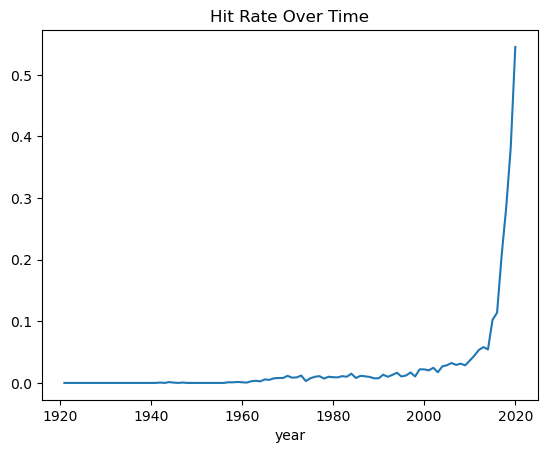

In [67]:
df.groupby("year")["hit"].mean().plot(
    title="Hit Rate Over Time"
)

In [68]:
# ============================
# Extra EDA 1: Quick overview
# ============================
print("Rows, Cols:", df.shape)
display(df.head(3))
display(df.sample(3, random_state=42))

print("\nColumn dtypes:")
display(df.dtypes.sort_values())

# memory usage
mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Approx memory usage: {mem_mb:.2f} MB")


Rows, Cols: (170653, 17)


,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,release_date,speechiness,tempo,hit
0,0.0594,1921,0.982,0.279,831667,0.211,0,0.878,10,0.665,-20.096,1,4,1921,0.0366,80.954,0
1,0.9630,1921,0.732,0.819,180533,0.341,0,0.000,7,0.160,-12.441,1,5,1921,0.4150,60.936,0
2,0.0394,1921,0.961,0.328,500062,0.166,0,0.913,3,0.101,-14.850,1,5,1921,0.0339,110.339,0


,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,release_date,speechiness,tempo,hit
116368,0.910,1977,0.500,0.894,273067,0.521,0,0.772,4,0.068,-7.048,1,34,1977,0.0847,126.805,0
161935,0.583,1976,0.930,0.585,182200,0.272,0,0.115,11,0.128,-16.693,0,26,1976,0.0802,90.104,0
135703,0.647,1994,0.157,0.878,179933,0.520,1,0.000,7,0.173,-12.609,1,38,1994-06-07,0.4030,90.744,0



Column dtypes:


hit                   int32
popularity            int64
mode                  int64
explicit              int64
key                   int64
year                  int64
duration_ms           int64
energy              float64
danceability        float64
instrumentalness    float64
tempo               float64
liveness            float64
loudness            float64
acousticness        float64
speechiness         float64
valence             float64
release_date         object
dtype: object

Approx memory usage: 29.49 MB


In [69]:
# =====================================
# Extra EDA 2: Duplicates / uniqueness
# =====================================
dup_rows = df.duplicated().sum()
print("Duplicate rows:", dup_rows, f"({dup_rows/len(df)*100:.2f}%)")

# Column-level uniqueness (helps spot IDs/categoricals)
uniq = df.nunique(dropna=False).sort_values(ascending=False)
display(uniq.to_frame("n_unique").head(15))

# If you have 'name'/'artists' dropped, try a near-duplicate check on remaining numeric cols
num_cols = df.select_dtypes(include="number").columns
if len(num_cols) > 0:
    dup_num = df[num_cols].duplicated().sum()
    print("Duplicate rows considering only numeric columns:", dup_num)


Duplicate rows: 710 (0.42%)


,n_unique
tempo,84694
duration_ms,51755
loudness,25410
release_date,11244
instrumentalness,5401
acousticness,4689
energy,2332
liveness,1740
valence,1733
speechiness,1626


Duplicate rows considering only numeric columns: 750


In [74]:
# =========================================
# Extra EDA 3: Missingness + target sanity
# =========================================
missing = df.isna().mean().sort_values(ascending=False)
display((missing * 100).to_frame("% missing").head(15))

print("\nHit distribution:")
display(df["hit"].value_counts().to_frame("count"))
display((df["hit"].value_counts(normalize=True) * 100).to_frame("%"))

# Hit rate by decade (temporal structure)
if "year" in df.columns:
    decade = (df["year"] // 10) * 10
    hit_by_decade = df.groupby(decade)["hit"].mean().sort_index()
    display(hit_by_decade.to_frame("hit_rate"))


,% missing
valence,0.0
liveness,0.0
tempo,0.0
speechiness,0.0
release_date,0.0
popularity,0.0
mode,0.0
loudness,0.0
key,0.0
year,0.0



Hit distribution:


,count
hit,
0,165638
1,5015


,%
hit,
0,97.061288
1,2.938712


,hit_rate
year,
1920,0.000000
1930,0.000000
1940,0.000260
1950,0.000353
1960,0.004502
1970,0.008950
1980,0.010176
1990,0.013215
2000,0.026112


Key numeric columns found: ['popularity', 'duration_ms', 'tempo', 'loudness', 'energy', 'danceability', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']


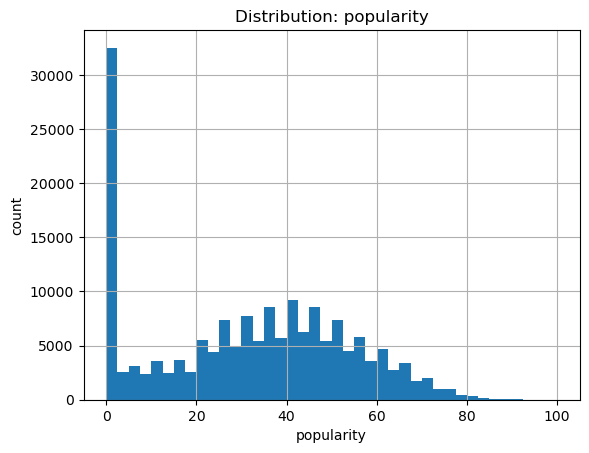

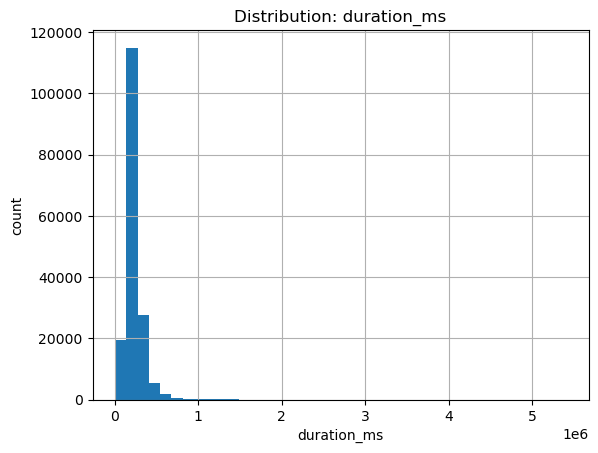

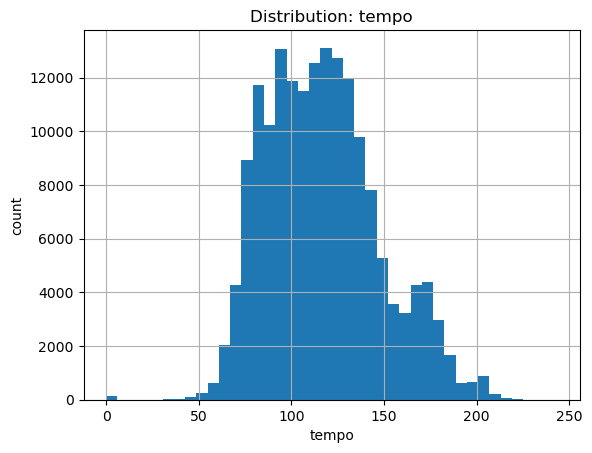

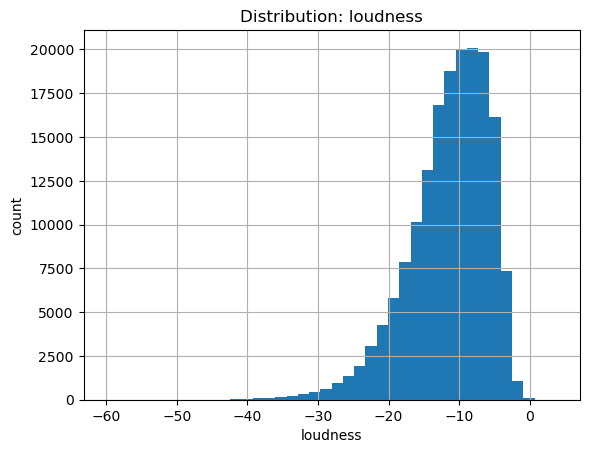

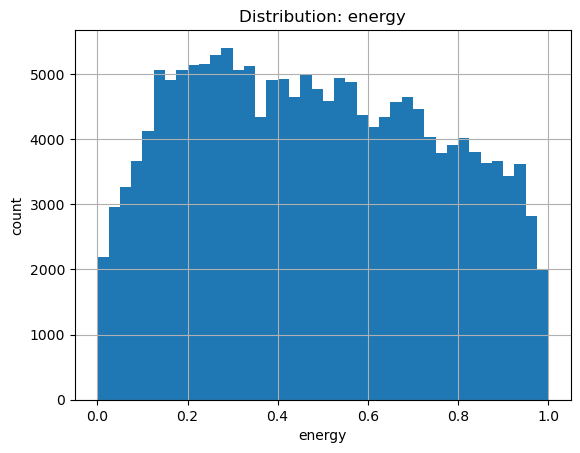

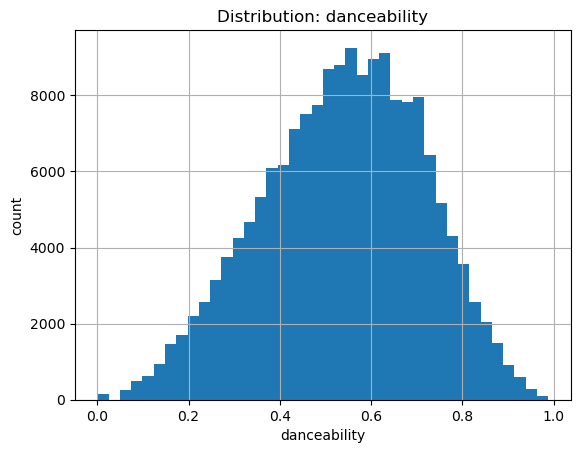

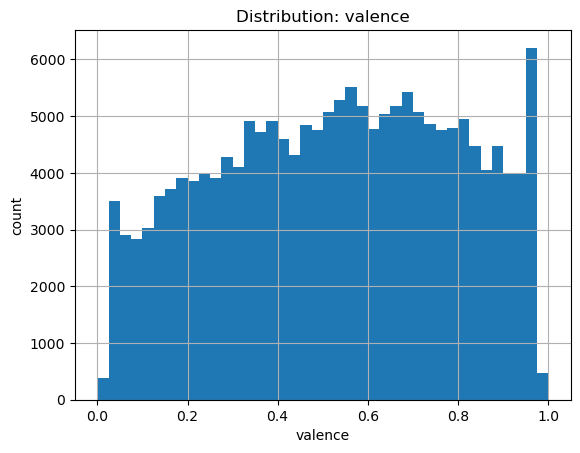

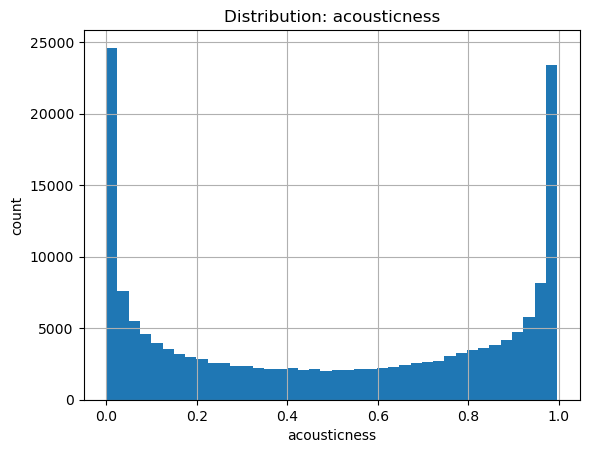

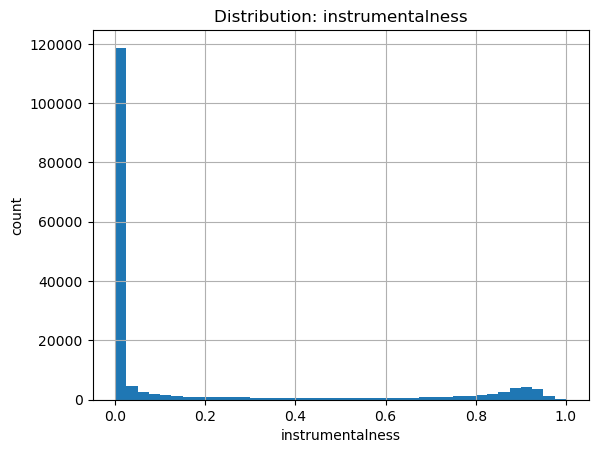

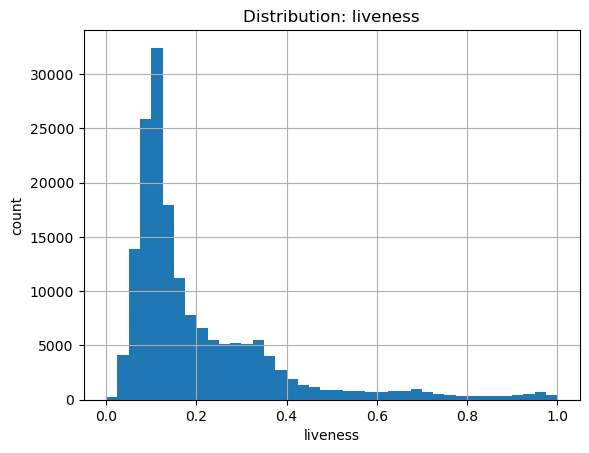

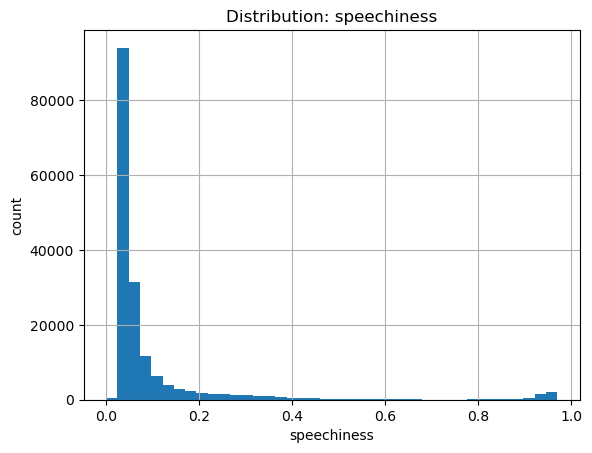

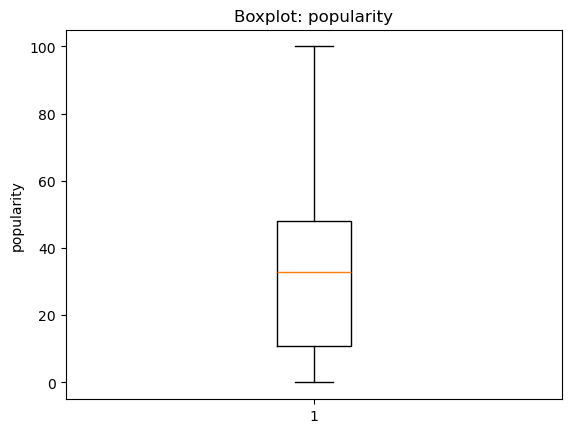

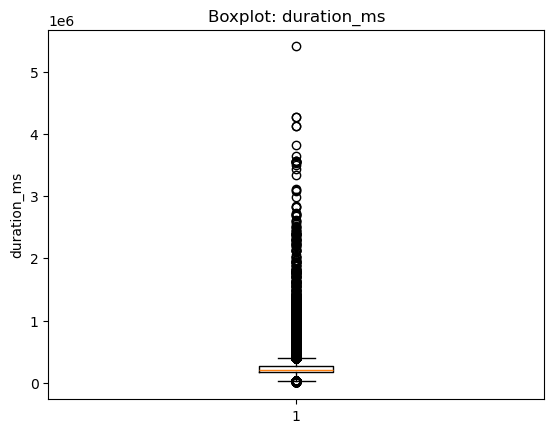

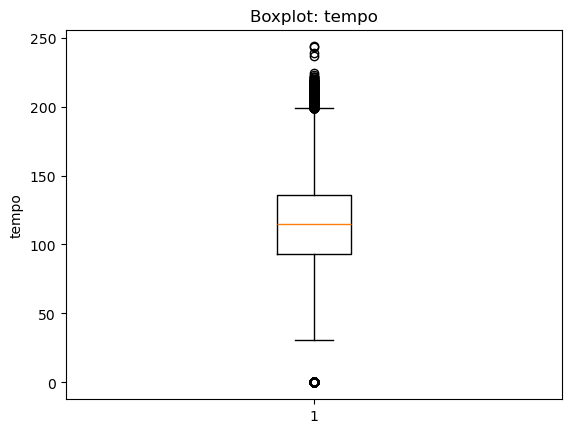

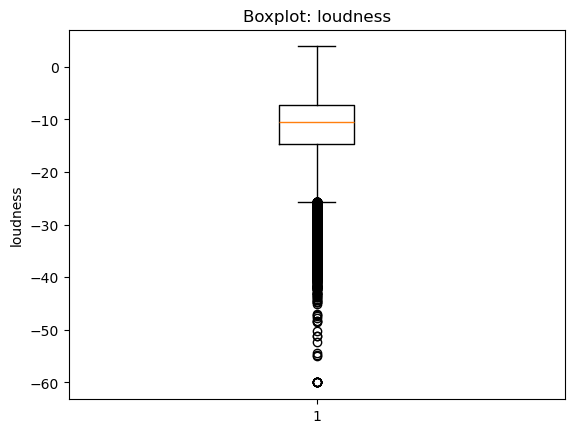

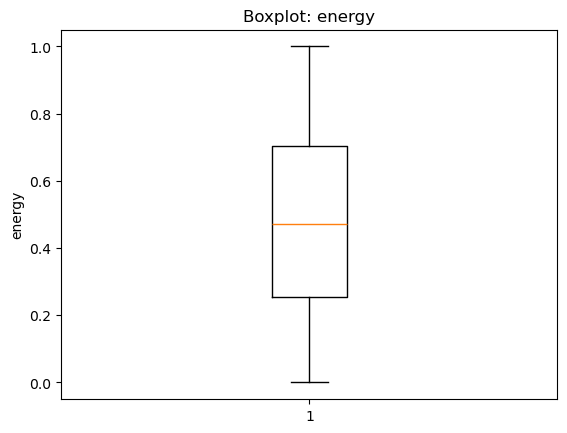

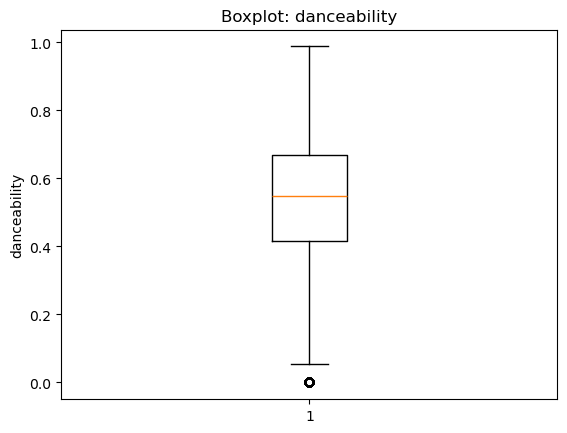

In [71]:
# ==================================================
# Extra EDA 4: Distributions of key numeric features
# ==================================================
import matplotlib.pyplot as plt

key_candidates = [
    "popularity","duration_ms","tempo","loudness","energy","danceability",
    "valence","acousticness","instrumentalness","liveness","speechiness"
]
key_cols = [c for c in key_candidates if c in df.columns]

print("Key numeric columns found:", key_cols)

for c in key_cols:
    plt.figure()
    df[c].hist(bins=40)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()

# Boxplot view for outliers (limited to first 6 columns to keep it readable)
for c in key_cols[:6]:
    plt.figure()
    plt.boxplot(df[c].dropna(), vert=True)
    plt.title(f"Boxplot: {c}")
    plt.ylabel(c)
    plt.show()


,corr_with_hit
hit,1.000000
popularity,0.345088
year,0.231244
explicit,0.150989
loudness,0.139489
danceability,0.106016
energy,0.097409
tempo,0.023871
speechiness,0.003341
key,0.002288


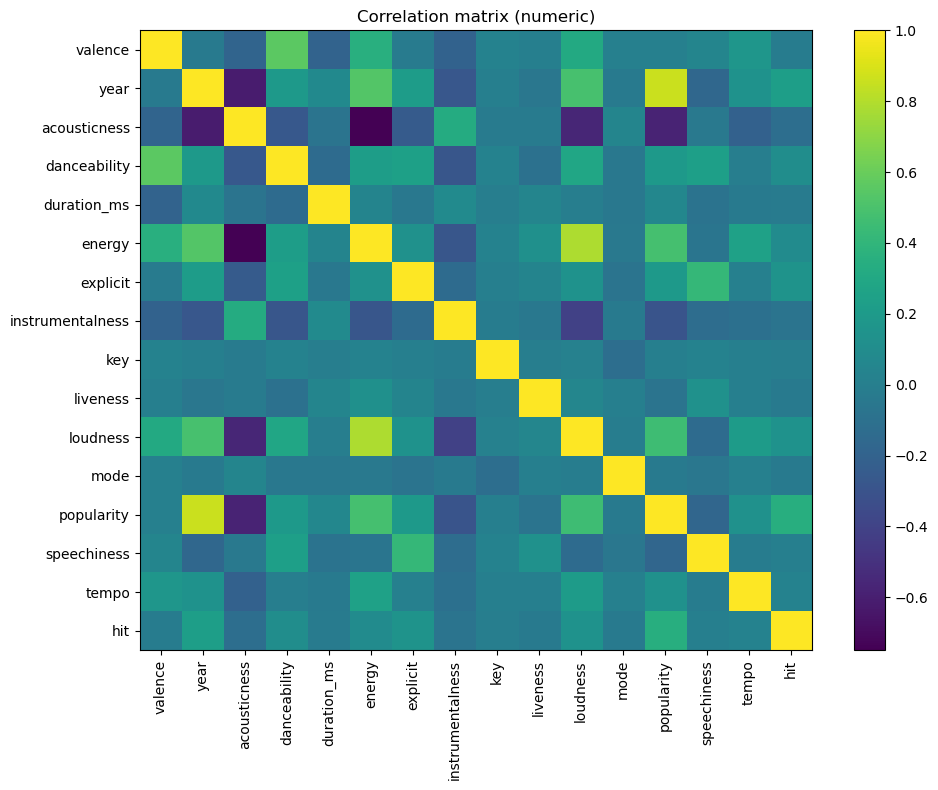

In [72]:
# =========================================
# Extra EDA 5: Correlations (numeric + hit)
# =========================================
import matplotlib.pyplot as plt
import numpy as np

num_df = df.select_dtypes(include="number").copy()

# Correlation with hit (most useful for quick feature ranking)
if "hit" in num_df.columns:
    corr_hit = num_df.corr(numeric_only=True)["hit"].dropna().sort_values(ascending=False)
    display(corr_hit.to_frame("corr_with_hit"))

# Full correlation heatmap (matplotlib only)
corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.imshow(corr.values, aspect="auto")
plt.title("Correlation matrix (numeric)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()


,mean_pop,hit_rate,n
year,,,
1921,0.653333,0.0,150
1922,0.140845,0.0,71
1923,5.389189,0.0,185
1924,0.661017,0.0,236
1925,2.604317,0.0,278


,mean_pop,hit_rate,n
year,,,
2016,59.647190,0.114079,1797
2017,63.263554,0.206827,1992
2018,63.296243,0.284356,2103
2019,65.256542,0.382247,1949
2020,64.301970,0.545320,2030


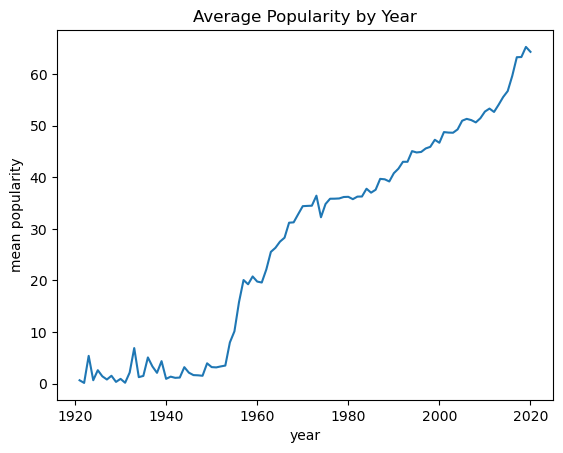

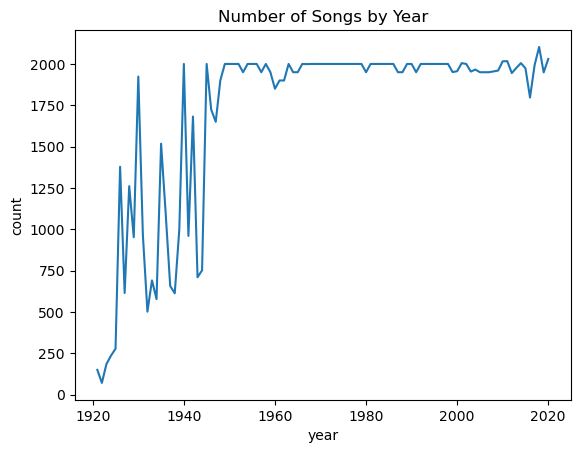

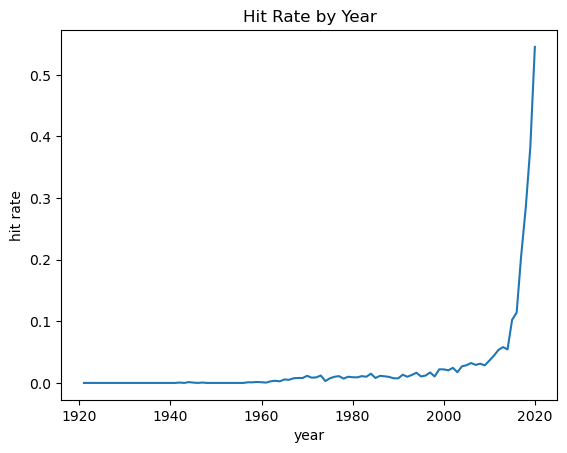

In [73]:
# ==========================================
# Extra EDA 6: Time trends (year vs features)
# ==========================================
import matplotlib.pyplot as plt

if "year" in df.columns:
    yearly = df.groupby("year").agg(
        mean_pop=("popularity","mean"),
        hit_rate=("hit","mean"),
        n=("hit","size")
    ).sort_index()

    display(yearly.head())
    display(yearly.tail())

    plt.figure()
    yearly["mean_pop"].plot(title="Average Popularity by Year")
    plt.ylabel("mean popularity")
    plt.show()

    plt.figure()
    yearly["n"].plot(title="Number of Songs by Year")
    plt.ylabel("count")
    plt.show()

    plt.figure()
    yearly["hit_rate"].plot(title="Hit Rate by Year")
    plt.ylabel("hit rate")
    plt.show()
else:
    print("No 'year' column found.")


In [75]:
# correlation with popularity and other features
corr_popularity = df.corr(numeric_only=True)["popularity"].dropna().sort_values(ascending=False)
display(corr_popularity.to_frame("corr_with_popularity"))

,corr_with_popularity
popularity,1.000000
year,0.862442
energy,0.485005
loudness,0.457051
hit,0.345088
danceability,0.199606
explicit,0.191543
tempo,0.133310
duration_ms,0.059597
valence,0.014200
